<a href="https://colab.research.google.com/github/Terry4715/MVO-backtest/blob/main/CodeAlong_Module3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import sys
from google.colab import drive


# Mount Google Drive
drive.mount('/content/drive/')

# Define the path to directory
data_path = '/content/drive/MyDrive/ColabNotebooks/EDHEC_Learning'

# Add the directory to sys.path to allow Python to find custom module
if data_path not in sys.path:
    sys.path.append(data_path)

# Import your custom module
import toolkit as tk

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# Build market index

In [6]:
ind = tk.get_ind_returns()
ind_size = tk.get_ind_size()
ind_nfirms = tk.get_ind_nfirms()
print(f'ind: {ind.shape}')
print(f'ind_size: {ind_size.shape}')
print(f'ind_nfirms: {ind_nfirms.shape}')

ind: (1110, 30)
ind_size: (1110, 30)
ind_nfirms: (1110, 30)


<Axes: >

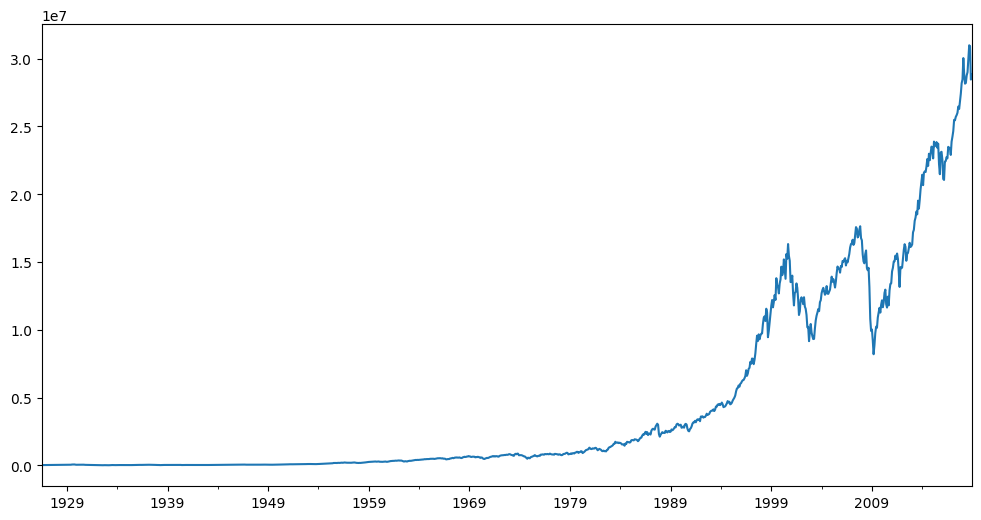

In [7]:
ind_mktcap = ind_nfirms * ind_size
# ind_mktcap.shape
total_mkcap = ind_mktcap.sum(axis='columns')
total_mkcap.plot(figsize=(12,6))

In [8]:
ind_capweight = ind_mktcap.divide(total_mkcap, axis='rows')
ind_capweight.head()

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
1926-07,0.058037,0.000801,0.035844,0.006935,0.000902,0.006683,0.008265,0.006701,0.036726,0.003014,...,0.065714,0.001531,0.014889,0.007956,0.185736,0.000089,0.057748,0.002435,0.008476,0.003639
1926-08,0.056578,0.000738,0.035264,0.006932,0.000972,0.006453,0.008673,0.006583,0.038497,0.002938,...,0.064380,0.001613,0.014732,0.008280,0.183379,0.000066,0.056014,0.002406,0.008258,0.003719
1926-09,0.056699,0.000917,0.036510,0.006810,0.001046,0.006038,0.008249,0.006668,0.039700,0.003109,...,0.064318,0.001609,0.014870,0.007873,0.187292,0.000068,0.054227,0.002339,0.008412,0.003879
1926-10,0.056920,0.000954,0.036736,0.007175,0.001028,0.006053,0.008139,0.006704,0.041486,0.003160,...,0.064896,0.001636,0.014850,0.007436,0.186812,0.000063,0.054280,0.002310,0.008280,0.003730
1926-11,0.056725,0.000951,0.038285,0.007047,0.001161,0.005924,0.008396,0.006831,0.040665,0.003269,...,0.066868,0.001642,0.015118,0.007236,0.187051,0.000054,0.054635,0.002279,0.008096,0.003521


In [9]:
ind_capweight.loc['1926'].sum(axis='columns')

,0
1926-07,1.0
1926-08,1.0
1926-09,1.0
1926-10,1.0
1926-11,1.0
1926-12,1.0


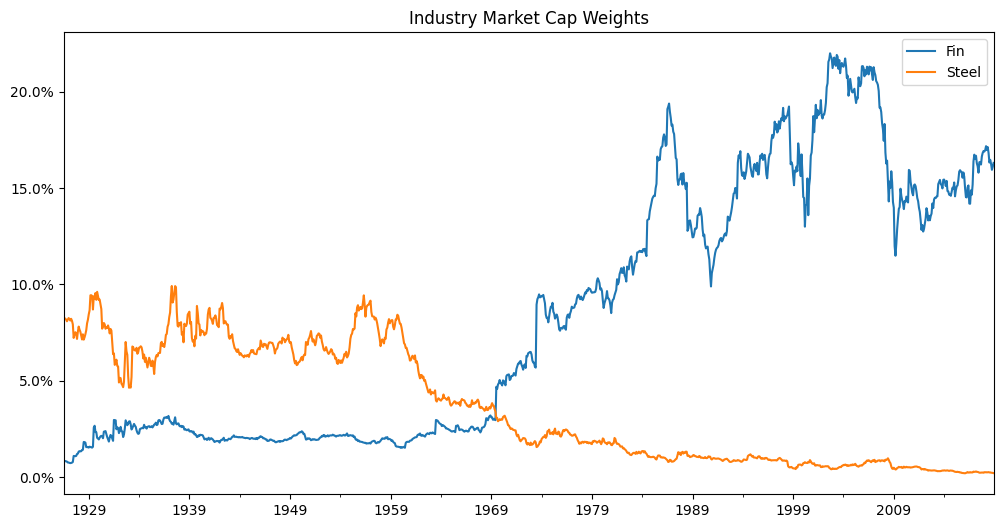

In [10]:
ax = ind_capweight[['Fin','Steel']].plot(figsize=(12,6), title="Industry Market Cap Weights")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=1))

<Axes: >

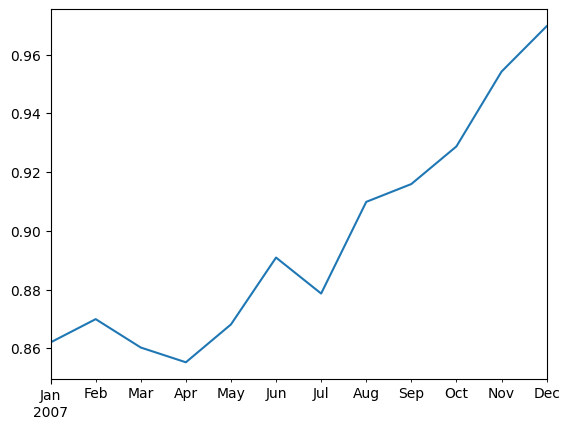

In [11]:
trd_period = ind_capweight.loc['2007']
ls_trd = trd_period['Beer'] / trd_period['Food']
ls_trd.plot()

<Axes: title={'center': 'Total Market Cap Weighted Index 1926-2018'}>

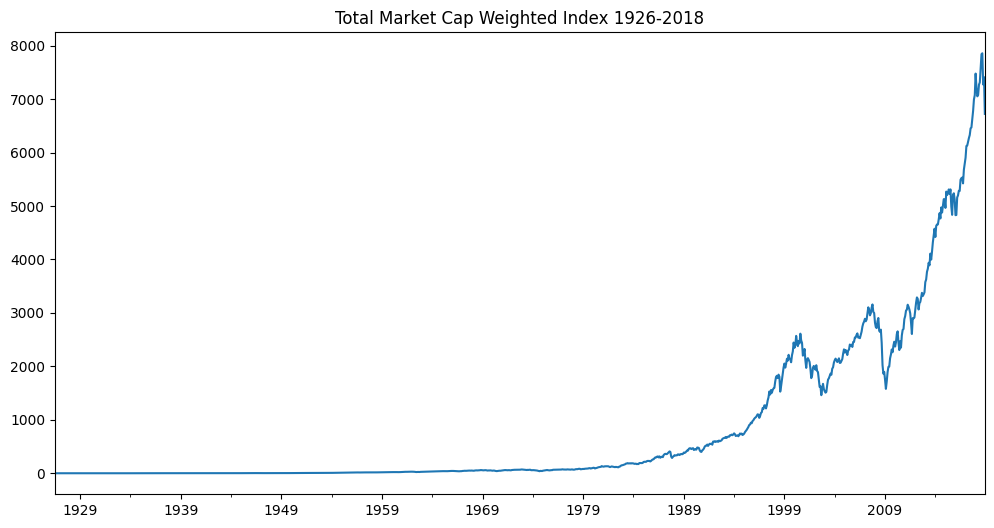

In [12]:
total_mkcap_rtn = (ind_capweight * ind).sum(axis='columns')
total_mkcap_index = (1 + total_mkcap_rtn).cumprod()
total_mkcap_index.plot(figsize=(12,6), title='Total Market Cap Weighted Index 1926-2018')

<Axes: >

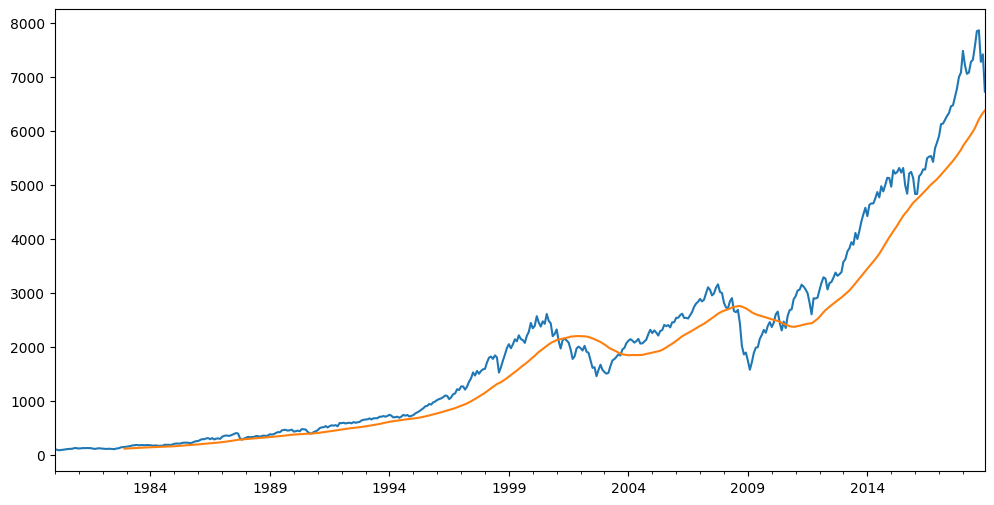

In [13]:
total_mkcap_index['1980':].plot(figsize=(12,6))
total_mkcap_index['1980':].rolling(window=36).mean().plot(figsize=(12,6))

<Axes: >

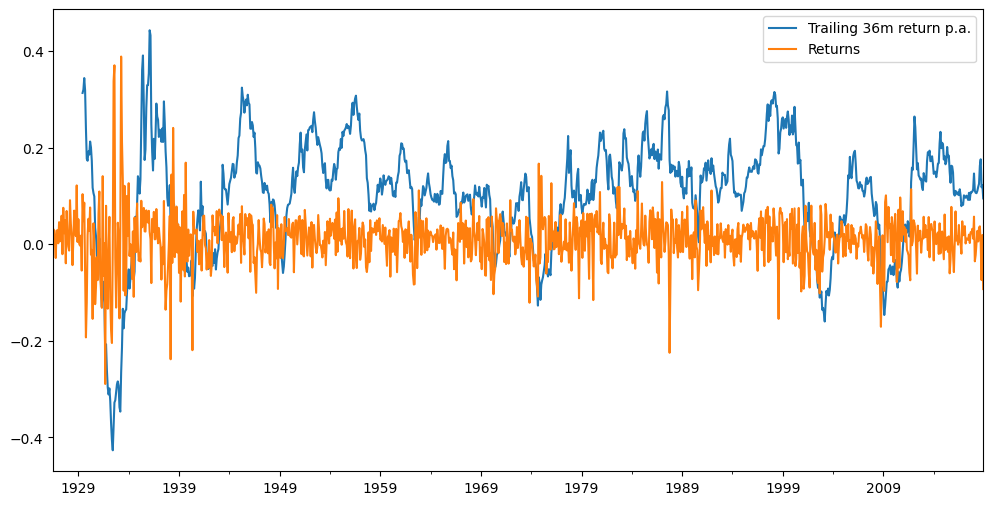

In [14]:
tmi_tr36rets = total_mkcap_rtn.rolling(window=36).aggregate(tk.ann_rets, periods_per_year=12)
tmi_tr36rets.plot(figsize=(12,6), label='Trailing 36m return p.a.', legend=True)
total_mkcap_rtn.plot(label='Returns', legend=True)

- Next step is to measure industry correlations over time

### Rolling correlations - along with multi-index and .groupby

In [15]:
ts_corr = ind.rolling(window=36).corr()
ts_corr.tail()

Food      Beer     Smoke     Games     Books     Hshld  \
2018-12 Whlsl  0.474948  0.356983  0.122672  0.510425  0.803362  0.419280   
        Rtail  0.517856  0.406107  0.030283  0.676464  0.636320  0.358336   
        Meals  0.370187  0.385483  0.122007  0.301516  0.520649  0.308216   
        Fin    0.298823  0.192706  0.027593  0.480276  0.694812  0.162690   
        Other  0.436952  0.376565  0.224010  0.331829  0.558072  0.390610   

                  Clths      Hlth     Chems     Txtls  ...     Telcm  \
2018-12 Whlsl  0.570071  0.739764  0.785796  0.634197  ...  0.648092   
        Rtail  0.676598  0.714933  0.626034  0.634202  ...  0.562238   
        Meals  0.302176  0.416193  0.520023  0.491726  ...  0.406184   
        Fin    0.425899  0.658468  0.760151  0.577090  ...  0.420863   
        Other  0.467099  0.645035  0.712511  0.520953  ...  0.607868   

                  Servs     BusEq     Paper     Trans     Whlsl     Rtail  \
2018-12 Whlsl  0.567395  0.543362  0.764252  0.829185  1.000000  0.744842   
        Rtail  0.762616  0.628246  0.656510  0.630615  0.744842  1.000000   
        Meals  0.444629  0.399438  0.627113  0.663358  0.643879  0.616947   
        Fin    0.585418  0.517947  0.670936  0.760730  0.746480  0.611883   
        Other  0.460322  0.434487  0.773798  0.756961  0.767652  0.619918   

                  Meals       Fin     Other  
2018-12 Whlsl  0.643879  0.746480  0.767652  
        Rtail  0.616947  0.611883  0.619918  
        Meals  1.000000  0.502563  0.605226  
        Fin    0.502563  1.000000  0.734837  
        Other  0.605226  0.734837  1.000000  

[5 rows x 30 columns]

In [16]:
ts_corr.index.names = ['date', 'industry']
ts_corr

Food      Beer     Smoke     Games     Books     Hshld  \
date    industry                                                               
1926-07 Food           NaN       NaN       NaN       NaN       NaN       NaN   
        Beer           NaN       NaN       NaN       NaN       NaN       NaN   
        Smoke          NaN       NaN       NaN       NaN       NaN       NaN   
        Games          NaN       NaN       NaN       NaN       NaN       NaN   
        Books          NaN       NaN       NaN       NaN       NaN       NaN   
...                    ...       ...       ...       ...       ...       ...   
2018-12 Whlsl     0.474948  0.356983  0.122672  0.510425  0.803362  0.419280   
        Rtail     0.517856  0.406107  0.030283  0.676464  0.636320  0.358336   
        Meals     0.370187  0.385483  0.122007  0.301516  0.520649  0.308216   
        Fin       0.298823  0.192706  0.027593  0.480276  0.694812  0.162690   
        Other     0.436952  0.376565  0.224010  0.331829  0.558072  0.390610   

                     Clths      Hlth     Chems     Txtls  ...     Telcm  \
date    industry                                          ...             
1926-07 Food           NaN       NaN       NaN       NaN  ...       NaN   
        Beer           NaN       NaN       NaN       NaN  ...       NaN   
        Smoke          NaN       NaN       NaN       NaN  ...       NaN   
        Games          NaN       NaN       NaN       NaN  ...       NaN   
        Books          NaN       NaN       NaN       NaN  ...       NaN   
...                    ...       ...       ...       ...  ...       ...   
2018-12 Whlsl     0.570071  0.739764  0.785796  0.634197  ...  0.648092   
        Rtail     0.676598  0.714933  0.626034  0.634202  ...  0.562238   
        Meals     0.302176  0.416193  0.520023  0.491726  ...  0.406184   
        Fin       0.425899  0.658468  0.760151  0.577090  ...  0.420863   
        Other     0.467099  0.645035  0.712511  0.520953  ...  0.607868   

                     Servs     BusEq     Paper     Trans     Whlsl     Rtail  \
date    industry                                                               
1926-07 Food           NaN       NaN       NaN       NaN       NaN       NaN   
        Beer           NaN       NaN       NaN       NaN       NaN       NaN   
        Smoke          NaN       NaN       NaN       NaN       NaN       NaN   
        Games          NaN       NaN       NaN       NaN       NaN       NaN   
        Books          NaN       NaN       NaN       NaN       NaN       NaN   
...                    ...       ...       ...       ...       ...       ...   
2018-12 Whlsl     0.567395  0.543362  0.764252  0.829185  1.000000  0.744842   
        Rtail     0.762616  0.628246  0.656510  0.630615  0.744842  1.000000   
        Meals     0.444629  0.399438  0.627113  0.663358  0.643879  0.616947   
        Fin       0.585418  0.517947  0.670936  0.760730  0.746480  0.611883   
        Other     0.460322  0.434487  0.773798  0.756961  0.767652  0.619918   

                     Meals       Fin     Other  
date    industry                                
1926-07 Food           NaN       NaN       NaN  
        Beer           NaN       NaN       NaN  
        Smoke          NaN       NaN       NaN  
        Games          NaN       NaN       NaN  
        Books          NaN       NaN       NaN  
...                    ...       ...       ...  
2018-12 Whlsl     0.643879  0.746480  0.767652  
        Rtail     0.616947  0.611883  0.619918  
        Meals     1.000000  0.502563  0.605226  
        Fin       0.502563  1.000000  0.734837  
        Other     0.605226  0.734837  1.000000  

[33300 rows x 30 columns]

<Axes: xlabel='date'>

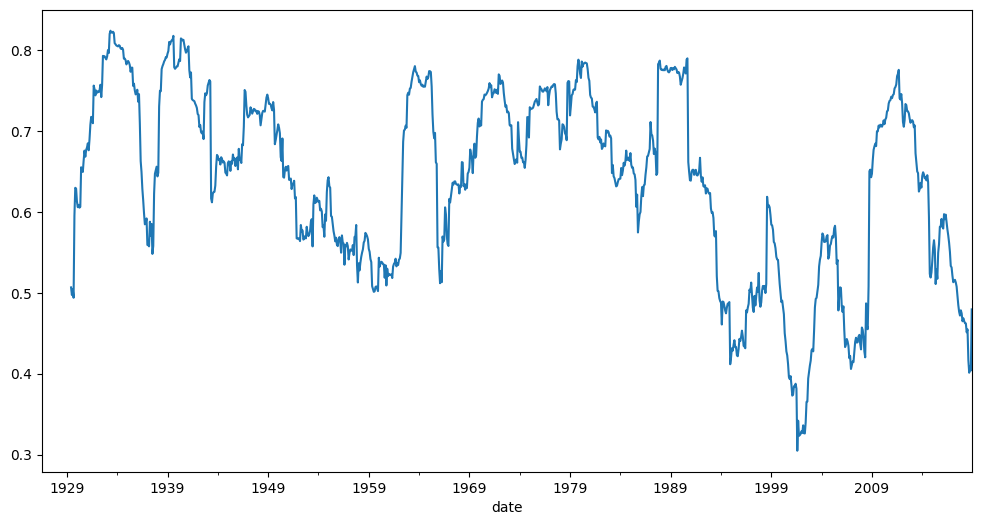

In [29]:
ind_tr36corr = ts_corr.groupby(level='date').apply(lambda cormat: cormat.values.mean())
ind_tr36corr.plot(figsize=(12,6))

<Axes: >

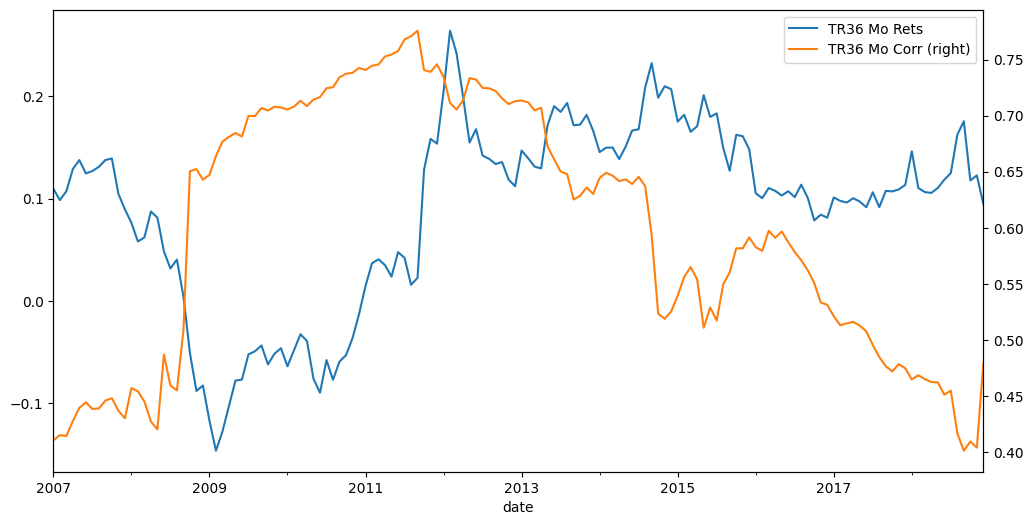

In [39]:
tmi_tr36rets['2007':].plot(label="TR36 Mo Rets", figsize=(12,6), legend=True)
ind_tr36corr['2007':].plot(label="TR36 Mo Corr", figsize=(12,6), legend=True, secondary_y=True)

In [40]:
tmi_tr36rets.corr(ind_tr36corr)

np.float64(-0.28010065062884026)